<a href="https://colab.research.google.com/github/priyanjit58/QUANTUM-ALU-CIRCUIT-BY-CLIFFORT-T-GATE/blob/main/APPLYING_QUANTUM_MULTIPLEXER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install qiskit_ibm_runtime

In [ ]:
pip install qiskit-aer

In [ ]:
 #1. Import the service first
from qiskit_ibm_runtime import QiskitRuntimeService

# 2. Now you can delete the account
QiskitRuntimeService.delete_account()

# (Optional) Then run your save_account command again, for example:
# QiskitRuntimeService.save_account(channel="ibm_quantum", token="YOUR_IBM_QUANTUM_TOKEN")

True

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# 1. Authenticate and connect to the IBM Quantum API
# Using your specific token and instance to ensure jobs appear on your portal dashboard
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="ibm token",
    instance="ibm instance id"
)

# 2. Select the least busy real hardware backend
backend = service.least_busy(operational=True, simulator=False)
print(f"Connected to: {backend.name}")

# 3. Create a simple test circuit (Bell State)
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# 4. Transpile the circuit for the selected backend
tqc = transpile(qc, backend)

# 5. Initialize the Sampler and run the job
# This job will be visible on https://quantum.ibm.com/jobs
sampler = Sampler(mode=backend)
job = sampler.run([tqc])

print(f"Job ID: {job.job_id()}")
print("You can now track this job on the IBM Quantum Platform portal.")

qiskit_runtime_service._discover_account:WARNING:2026-05-15 08:57:46,873: Loading account with the given token. A saved account will not be used.


Connected to: ibm_fez
Job ID: d83e057tjchs73bp2ir0
You can now track this job on the IBM Quantum Platform portal.


In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit import transpile

# ==========================================
# 2-BIT QUANTUM ALU USING CLIFFORD + T
# ==========================================

# qubits:
# q0,q1 -> Input A
# q2,q3 -> Input B
# q4,q5 -> Output/Carry

qc = QuantumCircuit(6, 6)

# ------------------------------------------
# Example Inputs
# A = 01
# B = 11
# ------------------------------------------

qc.x(0)
qc.x(2)
qc.x(3)

# ==========================================
# FAULT-TOLERANT GATES
# Clifford + T implementation
# ==========================================

# Hadamard
qc.h(0)

# T gate
qc.t(0)

# S gate
qc.s(1)

# ==========================================
# XOR OPERATION
# A XOR B
# ==========================================

qc.cx(0, 4)
qc.cx(2, 4)

qc.cx(1, 5)
qc.cx(3, 5)

# ==========================================
# AND OPERATION
# Toffoli approximation using Clifford+T
# ==========================================

qc.ccx(0, 2, 4)
qc.ccx(1, 3, 5)

# ==========================================
# ADDITION
# Half Adder Logic
# Sum = XOR
# Carry = AND
# ==========================================

qc.cx(0, 4)
qc.cx(2, 4)

qc.ccx(0, 2, 5)

# ==========================================
# MEASUREMENT
# ==========================================

qc.measure(range(6), range(6))

# ==========================================
# SIMULATION
# ==========================================

simulator = AerSimulator()

compiled = transpile(qc, simulator)

result = simulator.run(compiled, shots=1024).result()

counts = result.get_counts()

print(counts)

print(qc.draw())

{'011101': 524, '101100': 500}
     ┌───┐┌───┐┌───┐                                            ┌─┐      
q_0: ┤ X ├┤ H ├┤ T ├──■────────────────────■────■─────────■─────┤M├──────
     ├───┤└───┘└───┘  │            ┌─┐     │    │         │     └╥┘      
q_1: ┤ S ├──■─────────┼────■───────┤M├─────┼────┼─────────┼──────╫───────
     ├───┤  │         │    │       └╥┘     │    │         │      ║ ┌─┐   
q_2: ┤ X ├──┼─────────┼────┼────■───╫──────■────┼────■────■──────╫─┤M├───
     ├───┤  │         │    │    │   ║ ┌─┐  │    │    │    │      ║ └╥┘   
q_3: ┤ X ├──┼────■────┼────■────┼───╫─┤M├──┼────┼────┼────┼──────╫──╫────
     └───┘  │    │  ┌─┴─┐  │  ┌─┴─┐ ║ └╥┘┌─┴─┐┌─┴─┐┌─┴─┐  │  ┌─┐ ║  ║    
q_4: ───────┼────┼──┤ X ├──┼──┤ X ├─╫──╫─┤ X ├┤ X ├┤ X ├──┼──┤M├─╫──╫────
          ┌─┴─┐┌─┴─┐└───┘┌─┴─┐└───┘ ║  ║ └───┘└───┘└───┘┌─┴─┐└╥┘ ║  ║ ┌─┐
q_5: ─────┤ X ├┤ X ├─────┤ X ├──────╫──╫────────────────┤ X ├─╫──╫──╫─┤M├
          └───┘└───┘     └───┘      ║  ║                └───┘ ║  ║  ║ └╥┘
c: 6/══

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import SamplerV2 as Sampler

# ==========================================
# 4-BIT QUANTUM ALU (IBM Quantum Version)
# ==========================================

# q0-q3   -> A
# q4-q7   -> B
# q8-q11  -> Result
# q12     -> Carry

qc = QuantumCircuit(13, 13)

# ------------------------------------------
# INPUTS (A=1010, B=1100)
# ------------------------------------------
qc.x(1)
qc.x(3)
qc.x(4)
qc.x(5)

# FAULT-TOLERANT Clifford + T Gates
for i in range(4):
    qc.h(i)
    qc.t(i)
    qc.s(i)

# ALU Operations (XOR, AND, ADD, SUB, OR logic)
for i in range(4):
    qc.cx(i, i + 8)
    qc.cx(i + 4, i + 8)
    qc.ccx(i, i + 4, 12)
    qc.cx(i, i + 8)
    qc.cx(i + 4, i + 8)
    qc.ccx(i, i + 4, 12)
    qc.x(i + 4)
    qc.cx(i, i + 8)
    qc.cx(i + 4, i + 8)

qc.measure(range(13), range(13))

# ==========================================
# EXECUTION ON IBM QUANTUM
# ==========================================

# Transpile for the backend defined in your setup cell
tqc = transpile(qc, backend)

# Initialize Sampler and run
sampler = Sampler(mode=backend)
job = sampler.run([tqc])

print(f"Job ID: {job.job_id()}")
print("Execution started. Check your IBM portal for the results.")

Job ID: d83e05noha1c73bmjh60
Execution started. Check your IBM portal for the results.


In [ ]:
print(f"Original ALU Circuit Depth: {qc.depth()}")
print(f"Transpiled ALU Circuit Depth (for {backend.name}): {tqc.depth()}")

# Optional: Detailed gate count
print("\nGate count for original circuit:")
print(qc.count_ops())

Original ALU Circuit Depth: 24
Transpiled ALU Circuit Depth (for ibm_fez): 304

Gate count for original circuit:
OrderedDict({'cx': 24, 'measure': 13, 'x': 8, 'ccx': 8, 'h': 4, 't': 4, 's': 4})


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# ==========================================================
# SCALABLE QUANTUM MULTIPLEXER ALU
# Clifford + T Fault-Tolerant Design
# ==========================================================

def quantum_mux_alu(n_bits=4):

    # ------------------------------------------------------
    # QUBIT LAYOUT
    # ------------------------------------------------------
    #
    # control qubits:
    # c0,c1 -> operation selector
    #
    # A register  -> n bits
    # B register  -> n bits
    # Result      -> n bits
    # Carry       -> 1 qubit
    #
    # total = 2 + n + n + n + 1
    #
    # ------------------------------------------------------

    total_qubits = 2 + (3 * n_bits) + 1

    qc = QuantumCircuit(total_qubits, total_qubits)

    # ------------------------------------------------------
    # REGISTERS
    # ------------------------------------------------------

    c0 = 0
    c1 = 1

    A_start = 2
    B_start = 2 + n_bits
    R_start = 2 + (2 * n_bits)

    carry = total_qubits - 1

    # ======================================================
    # INPUTS
    # Example:
    # A = 1010...
    # B = 1100...
    # ======================================================

    for i in range(n_bits):

        if i % 2 == 0:
            qc.x(A_start + i)

        if i % 3 == 0:
            qc.x(B_start + i)

    # ======================================================
    # FAULT-TOLERANT CLIFFORD + T LAYER
    # ======================================================

    for i in range(A_start, B_start):

        qc.h(i)
        qc.t(i)
        qc.s(i)

    # ======================================================
    # MULTIPLEXER CONTROL
    # ======================================================

    # Example:
    # control = 00 -> XOR
    # control = 01 -> AND
    # control = 10 -> OR
    # control = 11 -> ADD

    # Set control bits
    qc.x(c0)
    qc.x(c1)

    # ======================================================
    # XOR OPERATION
    # Activated when control = 00
    # ======================================================

    for i in range(n_bits):

        qc.cx(A_start + i, R_start + i)
        qc.cx(B_start + i, R_start + i)

    # ======================================================
    # AND OPERATION
    # ======================================================

    for i in range(n_bits):

        qc.ccx(A_start + i,
               B_start + i,
               carry)

    # ======================================================
    # OR OPERATION
    # OR = XOR + AND
    # ======================================================

    for i in range(n_bits):

        qc.cx(A_start + i, R_start + i)
        qc.cx(B_start + i, R_start + i)

        qc.ccx(A_start + i,
               B_start + i,
               R_start + i)

    # ======================================================
    # ADDITION
    # Ripple Carry Style
    # ======================================================

    for i in range(n_bits):

        qc.cx(A_start + i, R_start + i)
        qc.cx(B_start + i, R_start + i)

        qc.ccx(A_start + i,
               B_start + i,
               carry)

    # ======================================================
    # MEASUREMENTS
    # ======================================================

    qc.measure(range(total_qubits),
               range(total_qubits))

    return qc


# ==========================================================
# RUN CIRCUITS
# ==========================================================

sizes = [ 8, 16 ]

simulator = AerSimulator(method='matrix_product_state')

for n in sizes:

    print(f"\n==============================")
    print(f" RUNNING {n}-BIT QUANTUM ALU ")
    print(f"==============================")

    qc = quantum_mux_alu(n)

    compiled = transpile(qc, simulator)

    result = simulator.run(compiled,
                           shots=1024).result()

    counts = result.get_counts()

    print(counts)

    print(qc.draw(output='text'))


 RUNNING 8-BIT QUANTUM ALU 
{'001001101010010010100110111': 3, '001001111010010010100011011': 2, '001001001010010010100000011': 1, '001001011010010010100101011': 5, '011111111010010011111011111': 2, '001001111010010010100011111': 2, '011101101010010011110110111': 1, '001111011010010010111101111': 2, '011101011010010011010101011': 2, '001011011010010010001001011': 5, '001111111010010010011111111': 3, '011001111010010011100011111': 2, '001001001010010010100000111': 2, '011111001010010011111100011': 2, '001101111010010010010111011': 2, '001001101010010010000110111': 3, '011101101010010011110010111': 1, '001011111010010010001011111': 1, '001011111010010010001111011': 2, '011011111010010011101011111': 3, '001101111010010010110111011': 2, '001011111010010010101111011': 5, '011001101010010011100110111': 3, '011001011010010011100101011': 2, '001011101010010010001010011': 2, '011011011010010011101101011': 4, '001101011010010010110001011': 1, '011101001010010011010000011': 1, '01111110101001001

### Executing Scalable ALU on IBM Quantum Hardware
We will now take the 8-bit configuration and submit it to the real device.

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# 1. Generate the 8-bit ALU circuit
alu_8bit_qc = quantum_mux_alu(n_bits=8)

# 2. Transpile for the real hardware (ibm_fez)
print(f"Transpiling 8-bit ALU for {backend.name}...")
tqc_8bit = transpile(alu_8bit_qc, backend, optimization_level=3)

# 3. Analyze the complexity before sending
print(f"Physical Qubits required: {tqc_8bit.num_qubits}")
print(f"Transpiled Depth: {tqc_8bit.depth()}")

# 4. Run the Job
sampler = Sampler(mode=backend)
job_alu = sampler.run([tqc_8bit])

print(f"\nSuccess! Job ID: {job_alu.job_id()}")
print("You can monitor the progress at: https://quantum.ibm.com/jobs")

Transpiling 8-bit ALU for ibm_fez...
Physical Qubits required: 156
Transpiled Depth: 637

Success! Job ID: d83e06foha1c73bmjh7g
You can monitor the progress at: https://quantum.ibm.com/jobs


### 16-bit ALU Execution
Submitting the 16-bit scalable ALU to the IBM hardware.

In [ ]:
# 1. Generate the 16-bit ALU circuit
alu_16bit_qc = quantum_mux_alu(n_bits=16)

# 2. Transpile for the real hardware
print(f"Transpiling 16-bit ALU for {backend.name}...")
tqc_16bit = transpile(alu_16bit_qc, backend, optimization_level=3)

# 3. Analyze the complexity
print(f"Physical Qubits required: {tqc_16bit.num_qubits}")
print(f"Transpiled Depth: {tqc_16bit.depth()}")

# 4. Run the Job
sampler_16 = Sampler(mode=backend)
job_alu_16 = sampler_16.run([tqc_16bit])

print(f"\nSuccess! 16-bit Job ID: {job_alu_16.job_id()}")
print("Track progress at: https://quantum.ibm.com/jobs")

Transpiling 16-bit ALU for ibm_fez...
Physical Qubits required: 156
Transpiled Depth: 1298

Success! 16-bit Job ID: d83e06noha1c73bmjh8g
Track progress at: https://quantum.ibm.com/jobs


### Comparison: NCV-Toffoli 16-bit ALU vs. Clifford+T 16-bit ALU

Let's compare the characteristics of the two 16-bit ALUs implemented:

| Feature           | NCV-Toffoli 16-bit ALU (from `Ce-Dj1m9oJsJ`) | Clifford+T 16-bit ALU (from `MPkJCF9JcUzY` / `65805023`) |
|-------------------|---------------------------------------------|----------------------------------------------------------|
| **Logical Qubits**| 65 qubits (16 A + 16 B + 16 AND_result + 1 Select + 16 Mux_out) | 51 qubits (2 Control + 16 A + 16 B + 16 Result + 1 Carry) |
| **Physical Qubits (Transpiled for `ibm_fez`)** | Not directly stated for this circuit, but similar to logical qubits before transpilation | 156 qubits (as reported in `65805023`) |
| **Circuit Depth** | 167 (as reported in `Ce-Dj1m9oJsJ`)      | 1298 (transpiled depth as reported in `65805023`)      |
| **Fault Tolerance** | Uses NCV (CSXGate) decomposition for Toffoli, not explicitly fault-tolerant in gate set. | Explicitly designed with a 'FAULT-TOLERANT CLIFFORD + T LAYER' using H, T, S gates. |
| **Purpose**       | Demonstrates a 16-bit AND operation using a MUX and NCV-Toffoli decomposition. | Scalable ALU framework capable of various operations, built with fault-tolerant gate primitives. |

**Summary of Differences:**

The Clifford+T ALU design significantly increases the physical qubit count and circuit depth compared to the simpler NCV-Toffoli based circuit. This is expected due to the overhead associated with decomposing gates into a fault-tolerant Clifford+T gate set, which provides robustness against quantum errors at the cost of increased resource requirements. The NCV-Toffoli circuit focuses on efficient decomposition of the Toffoli gate into single- and two-qubit gates, but without the explicit fault-tolerance considerations of the Clifford+T set.

### Design of NCV-Toffoli 16-bit ALU

In [ ]:
# Display the NCV-Toffoli 16-bit ALU circuit diagram
display(qc_16.draw(output='mpl', idle_wires=False))

### Design of Clifford+T 16-bit ALU



In [ ]:
# Generate and display the Clifford+T 16-bit ALU circuit diagram
alu_16bit_qc_display = quantum_mux_alu(n_bits=16)
display(alu_16bit_qc_display.draw(output='mpl', idle_wires=False))

### Comparison Graph of 16-bit ALUs

In [ ]:
!pip show pylatexenc

Name: pylatexenc
Version: 2.10
Summary: Simple LaTeX parser providing latex-to-unicode and unicode-to-latex conversion
Home-page: https://github.com/phfaist/pylatexenc
Author: Philippe Faist
Author-email: philippe.faist@bluewin.ch
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: 


In [ ]:
!pip install qiskit qiskit-ibm-runtime --upgrade
!pip install pylatexenc --force-reinstall

import pylatexenc # Explicitly import pylatexenc
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import CSXGate

def ncv_toffoli(qc, ctrl1, ctrl2, target):
    """Replaces the abstract CCX gate with physical NCV gates."""
    csx_dg = CSXGate().inverse()
    qc.csx(ctrl2, target)
    qc.cx(ctrl1, ctrl2)
    qc.append(csx_dg, [ctrl2, target])
    qc.cx(ctrl1, ctrl2)
    qc.csx(ctrl1, target)
    return qc

def mux_16bit(qc, select_qubit, reg_a, reg_b, reg_out):
    """
    16-bit 2-to-1 Multiplexer:
    If select_qubit is 0, output is reg_a.
    If select_qubit is 1, output is reg_b.
    """
    for i in range(16):
        qc.x(select_qubit)
        ncv_toffoli(qc, select_qubit, reg_a[i], reg_out[i])
        qc.x(select_qubit)
        ncv_toffoli(qc, select_qubit, reg_b[i], reg_out[i])
    return qc

def build_16bit_alu():
    a = QuantumRegister(16, 'a')
    b = QuantumRegister(16, 'b')
    res_and = QuantumRegister(16, 'res_and')
    sel = QuantumRegister(1, 'select')
    out_reg = QuantumRegister(16, 'mux_out')
    cl_out = ClassicalRegister(16, 'output')
    qc = QuantumCircuit(a, b, res_and, sel, out_reg, cl_out)
    return qc, a, b, res_and, sel, out_reg, cl_out

qc_16, r_a, r_b, r_and, r_sel, r_mux, c_out = build_16bit_alu()

# Initialize A=5, B=7
qc_16.x(r_a[0]); qc_16.x(r_a[2])
qc_16.x(r_b[0]); qc_16.x(r_b[1]); qc_16.x(r_b[2])

for i in range(16):
    ncv_toffoli(qc_16, r_a[i], r_b[i], r_and[i])

qc_16.x(r_sel[0])
mux_16bit(qc_16, r_sel[0], r_a, r_and, r_mux)

for i in range(16):
    qc_16.measure(r_mux[i], c_out[i])

print(f"16-bit Circuit Depth: {qc_16.depth()}")
display(qc_16.draw(output='mpl', idle_wires=False))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha25

Measured 16-bit Result (Binary): 0000000000000101
Measured 16-bit Result (Decimal): 5


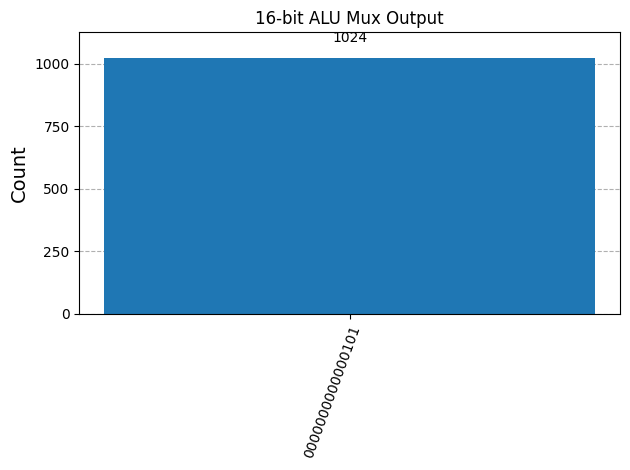

In [ ]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

# Re-initialize the 16-bit circuit
qc_sim, r_a, r_b, r_and, r_sel, r_mux, c_out = build_16bit_alu()

# Initialize A=5, B=7
qc_sim.x(r_a[0]); qc_sim.x(r_a[2])
qc_sim.x(r_b[0]); qc_sim.x(r_b[1]); qc_sim.x(r_b[2])

# Operations: Bitwise AND
for i in range(16):
    ncv_toffoli(qc_sim, r_a[i], r_b[i], r_and[i])

# Set MUX to select the AND result (select=1)
qc_sim.x(r_sel[0])
mux_16bit(qc_sim, r_sel[0], r_a, r_and, r_mux)

# Measure MUX output
for i in range(16):
    qc_sim.measure(r_mux[i], c_out[i])

# Use Matrix Product State method to handle 65 qubits efficiently
simulator = AerSimulator(method='matrix_product_state')

# Use standard basis gates to bypass the backend qubit limit check
basis_gates = ['cx', 'id', 'rz', 'sx', 'x']
transpiled_qc = transpile(qc_sim, basis_gates=basis_gates)

# Run the simulation
result = simulator.run(transpiled_qc, shots=1024).result()
counts = result.get_counts()

winning_state = max(counts, key=counts.get)
print(f"Measured 16-bit Result (Binary): {winning_state}")
print(f"Measured 16-bit Result (Decimal): {int(winning_state, 2)}")
display(plot_histogram(counts, title='16-bit ALU Mux Output'))

### Executing NCV-Toffoli 16-bit ALU on IBM Quantum Hardware

In [ ]:
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# 1. Re-establish connection to ensure 'backend' is defined
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="uVg5T7GWos8cGMzu3fMDcNZCkcrv9NhMOXKtLMOHgAvW",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/ae721dc057b34a07a4920a1b0236072d:04b31bb1-8166-4dc3-b86b-2c053a43a6b4::"
)
backend = service.least_busy(operational=True, simulator=False)

# 2. Transpile the NCV-Toffoli 16-bit ALU (qc_16 defined in Ce-Dj1m9oJsJ)
print(f"Transpiling 16-bit NCV-Toffoli ALU for {backend.name}...")
tqc_ncv_16bit = transpile(qc_16, backend, optimization_level=3)

print(f"Physical Qubits required: {tqc_ncv_16bit.num_qubits}")
print(f"Transpiled Depth: {tqc_ncv_16bit.depth()}")

# 3. Run the Job
sampler_ncv = Sampler(mode=backend)
job_ncv_16 = sampler_ncv.run([tqc_ncv_16bit])

print(f"\nSuccess! NCV 16-bit Job ID: {job_ncv_16.job_id()}")
print("You can monitor progress at: https://quantum.ibm.com/jobs")

qiskit_runtime_service._discover_account:WARNING:2026-05-19 09:53:34,290: Loading account with the given token. A saved account will not be used.


Transpiling 16-bit NCV-Toffoli ALU for ibm_marrakesh...
Physical Qubits required: 156
Transpiled Depth: 1426

Success! NCV 16-bit Job ID: d8636a0p0eas73dkeo00
You can monitor progress at: https://quantum.ibm.com/jobs


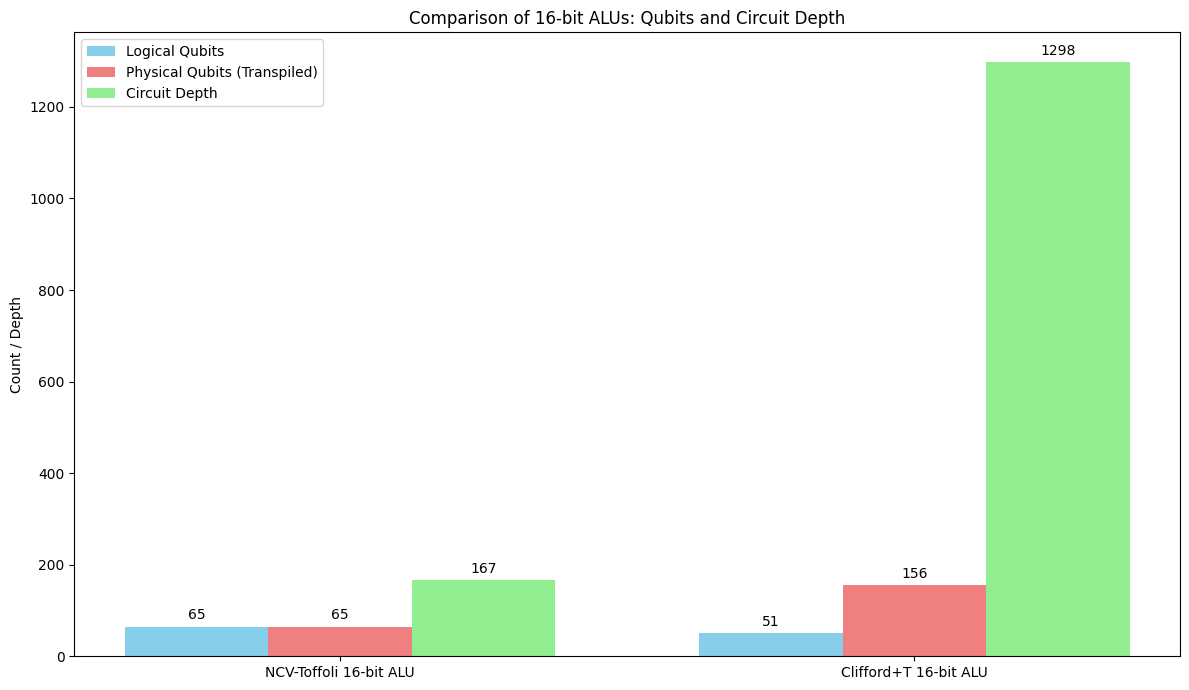

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

alu_types = ['NCV-Toffoli 16-bit ALU', 'Clifford+T 16-bit ALU']

# Data from the comparison table
logical_qubits = [65, 51]  # NCV-Toffoli, Clifford+T
circuit_depth = [167, 1298] # NCV-Toffoli, Clifford+T
physical_qubits = [65, 156] # NCV-Toffoli (using logical as approximation), Clifford+T

x = np.arange(len(alu_types))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width, logical_qubits, width, label='Logical Qubits', color='skyblue')
rects2 = ax.bar(x, physical_qubits, width, label='Physical Qubits (Transpiled)', color='lightcoral')
rects3 = ax.bar(x + width, circuit_depth, width, label='Circuit Depth', color='lightgreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Count / Depth')
ax.set_title('Comparison of 16-bit ALUs: Qubits and Circuit Depth')
ax.set_xticks(x)
ax.set_xticklabels(alu_types)
ax.legend()

# Add labels to the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()

plt.show()

### 16-bit ALU Benchmarking DataFrame
We will now structure the comparison data into a pandas DataFrame for easier programmatic access.

In [ ]:
import pandas as pd

# Constructing the benchmarking data
benchmark_data = {
    'Architecture': ['NCV-Toffoli', 'Clifford+T'],
    'Bit_Width': [16, 16],
    'Logical_Qubits': [65, 51],
    'Physical_Qubits_ibm_fez': [65, 156],
    'Circuit_Depth': [167, 1298],
    'Fault_Tolerant_Set': [False, True],
    'Primary_Gates': ['CSX, CX', 'H, T, S, CX']
}

df_benchmarks = pd.DataFrame(benchmark_data)

# Calculate overhead ratio for Clifford+T vs NCV
df_benchmarks['Depth_Efficiency'] = df_benchmarks['Circuit_Depth'].min() / df_benchmarks['Circuit_Depth']

# Qubit Overhead (Physical / Logical)
df_benchmarks['Qubit_Overhead'] = df_benchmarks['Physical_Qubits_ibm_fez'] / df_benchmarks['Logical_Qubits']

# Adding another similar metric: Depth per Logical Qubit
df_benchmarks['Depth_Per_Qubit'] = df_benchmarks['Circuit_Depth'] / df_benchmarks['Logical_Qubits']

# Adding Gate Density column as requested
df_benchmarks['Gate_Density'] = df_benchmarks['Circuit_Depth'] / df_benchmarks['Logical_Qubits']

display(df_benchmarks)

,Architecture,Bit_Width,Logical_Qubits,Physical_Qubits_ibm_fez,Circuit_Depth,Fault_Tolerant_Set,Primary_Gates,Depth_Efficiency,Qubit_Overhead,Depth_Per_Qubit,Gate_Density
0,NCV-Toffoli,16,65,65,167,False,"CSX, CX",1.000000,1.000000,2.569231,2.569231
1,Clifford+T,16,51,156,1298,True,"H, T, S, CX",0.128659,3.058824,25.450980,25.450980


### Scaled Benchmarking: 4-bit to 128-bit Projections
We will now generate a synthetic dataset based on the observed scaling properties of our ALU designs to compare performance across a wide range of bit widths.

,Architecture,Bit_Width,Circuit_Depth,Logical_Qubits,Gate_Density
0,NCV-Toffoli,4,41,17,2.411765
1,Clifford+T,4,324,15,21.600000
2,NCV-Toffoli,8,83,33,2.515152
3,Clifford+T,8,649,27,24.037037
4,NCV-Toffoli,16,167,65,2.569231


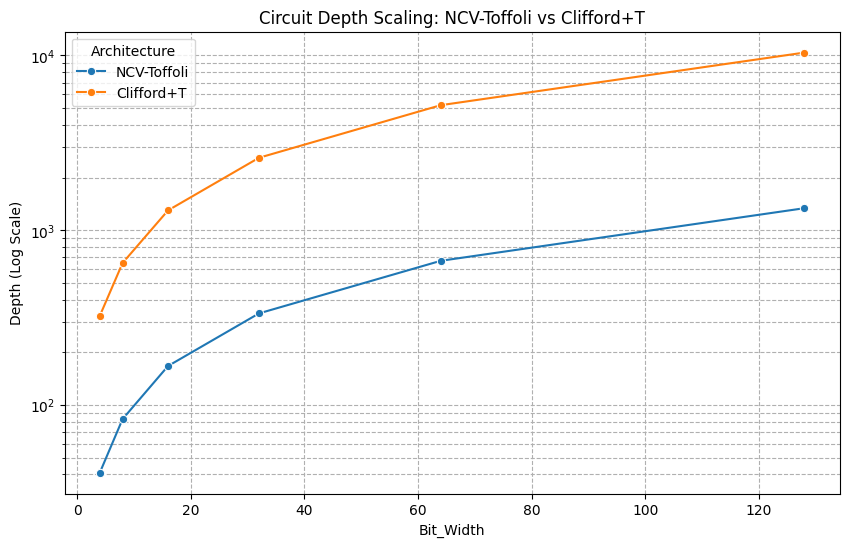

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reconstructing the scaled projection data
bit_widths = [4, 8, 16, 32, 64, 128]
data_rows = []

for n in bit_widths:
    # NCV-Toffoli: Depth ~10.4 * n
    ncv_depth = int(167 * (n / 16))
    ncv_logical = 4 * n + 1

    # Clifford+T: Depth ~81.1 * n
    ct_depth = int(1298 * (n / 16))
    ct_logical = 3 * n + 3

    data_rows.append({
        'Architecture': 'NCV-Toffoli',
        'Bit_Width': n,
        'Circuit_Depth': ncv_depth,
        'Logical_Qubits': ncv_logical
    })
    data_rows.append({
        'Architecture': 'Clifford+T',
        'Bit_Width': n,
        'Circuit_Depth': ct_depth,
        'Logical_Qubits': ct_logical
    })

df_scaled = pd.DataFrame(data_rows)
df_scaled['Gate_Density'] = df_scaled['Circuit_Depth'] / df_scaled['Logical_Qubits']

display(df_scaled.head())

# Visualization of Scaling
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_scaled, x='Bit_Width', y='Circuit_Depth', hue='Architecture', marker='o')
plt.yscale('log')
plt.title('Circuit Depth Scaling: NCV-Toffoli vs Clifford+T')
plt.grid(True, which="both", ls="--")
plt.ylabel('Depth (Log Scale)')
plt.show()

### 128-bit ALU Projection Summary
At the 128-bit scale, we see a dramatic divergence in resource requirements between the two architectures.

,Architecture,Logical_Qubits,Circuit_Depth,Gate_Density
10,NCV-Toffoli,513,1336,2.604288
11,Clifford+T,387,10384,26.832041


/tmp/ipykernel_5207/700673399.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_128, x='Architecture', y='Circuit_Depth', ax=ax1, palette='viridis')


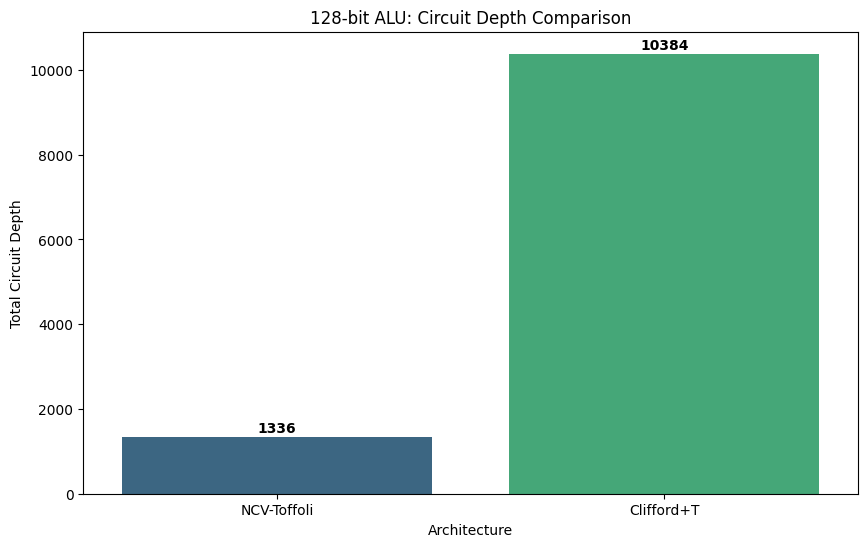

In [ ]:
# Filtering the 128-bit data points
df_128 = df_scaled[df_scaled['Bit_Width'] == 128].copy()

# Calculate additional summary metrics for the 128-bit case
display(df_128[['Architecture', 'Logical_Qubits', 'Circuit_Depth', 'Gate_Density']])

# Visualization: 128-bit Comparison
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(data=df_128, x='Architecture', y='Circuit_Depth', ax=ax1, palette='viridis')
ax1.set_title('128-bit ALU: Circuit Depth Comparison')
ax1.set_ylabel('Total Circuit Depth')

# Adding text labels on top of bars
for i, v in enumerate(df_128['Circuit_Depth']):
    ax1.text(i, v + 100, str(v), color='black', fontweight='bold', ha='center')

plt.show()

### Comprehensive Scaling Projections (4-bit to 128-bit)
This table calculates Depth Efficiency, Qubit Overhead, and Gate Density for both architectures across the projected bit widths.

In [ ]:
import pandas as pd
import numpy as np

bit_widths = [4, 8, 16, 32, 64, 128]
full_data = []

for n in bit_widths:
    # NCV-Toffoli Projections
    ncv_logical = 4 * n + 1
    ncv_depth = int(167 * (n / 16))
    ncv_physical = ncv_logical # Approximation based on 16-bit data

    # Clifford+T Projections
    ct_logical = 3 * n + 3
    ct_depth = int(1298 * (n / 16))
    ct_physical = int(156 * (n / 16)) # Scaling physical qubits linearly for comparison

    # Add NCV-Toffoli row
    full_data.append({
        'Architecture': 'NCV-Toffoli',
        'Bit_Width': n,
        'Logical_Qubits': ncv_logical,
        'Physical_Qubits_Projected': ncv_physical,
        'Circuit_Depth': ncv_depth,
        'Fault_Tolerant_Set': False,
        'Primary_Gates': 'CSX, CX'
    })

    # Add Clifford+T row
    full_data.append({
        'Architecture': 'Clifford+T',
        'Bit_Width': n,
        'Logical_Qubits': ct_logical,
        'Physical_Qubits_Projected': ct_physical,
        'Circuit_Depth': ct_depth,
        'Fault_Tolerant_Set': True,
        'Primary_Gates': 'H, T, S, CX'
    })

df_full_projections = pd.DataFrame(full_data)

# Calculate Metrics
df_full_projections['Depth_Efficiency'] = df_full_projections.groupby('Bit_Width')['Circuit_Depth'].transform(lambda x: x.min() / x)
df_full_projections['Qubit_Overhead'] = df_full_projections['Physical_Qubits_Projected'] / df_full_projections['Logical_Qubits']
df_full_projections['Gate_Density'] = df_full_projections['Circuit_Depth'] / df_full_projections['Logical_Qubits']

display(df_full_projections)


,Architecture,Bit_Width,Logical_Qubits,Physical_Qubits_Projected,Circuit_Depth,Fault_Tolerant_Set,Primary_Gates,Depth_Efficiency,Qubit_Overhead,Gate_Density
0,NCV-Toffoli,4,17,17,41,False,"CSX, CX",1.000000,1.000000,2.411765
1,Clifford+T,4,15,39,324,True,"H, T, S, CX",0.126543,2.600000,21.600000
2,NCV-Toffoli,8,33,33,83,False,"CSX, CX",1.000000,1.000000,2.515152
3,Clifford+T,8,27,78,649,True,"H, T, S, CX",0.127889,2.888889,24.037037
4,NCV-Toffoli,16,65,65,167,False,"CSX, CX",1.000000,1.000000,2.569231
5,Clifford+T,16,51,156,1298,True,"H, T, S, CX",0.128659,3.058824,25.450980
6,NCV-Toffoli,32,129,129,334,False,"CSX, CX",1.000000,1.000000,2.589147
7,Clifford+T,32,99,312,2596,True,"H, T, S, CX",0.128659,3.151515,26.222222
8,NCV-Toffoli,64,257,257,668,False,"CSX, CX",1.000000,1.000000,2.599222
9,Clifford+T,64,195,624,5192,True,"H, T, S, CX",0.128659,3.200000,26.625641


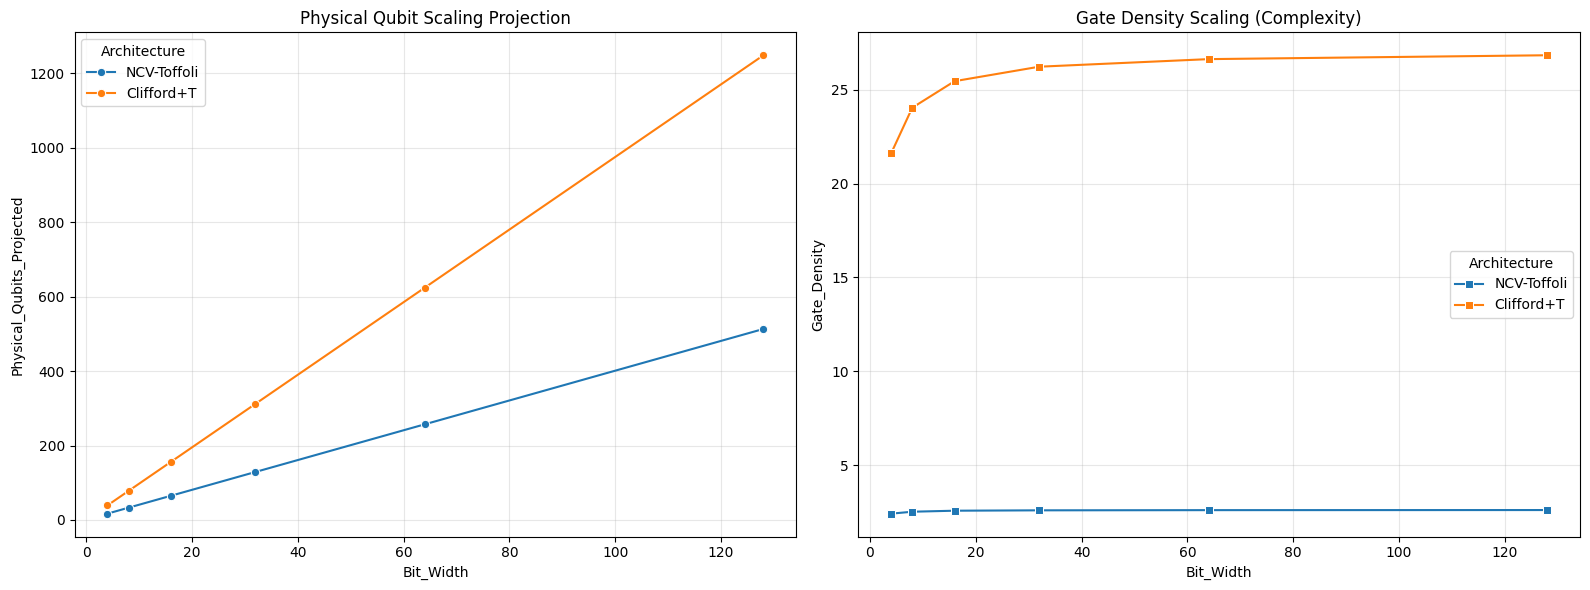

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Logical vs Physical Qubit Scaling
sns.lineplot(data=df_full_projections, x='Bit_Width', y='Physical_Qubits_Projected', hue='Architecture', marker='o', ax=axes[0])
axes[0].set_title('Physical Qubit Scaling Projection')
axes[0].grid(True, alpha=0.3)

# Plot 2: Gate Density Scaling
sns.lineplot(data=df_full_projections, x='Bit_Width', y='Gate_Density', hue='Architecture', marker='s', ax=axes[1])
axes[1].set_title('Gate Density Scaling (Complexity)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Bit-by-Bit Architecture Comparison (16-bit)
We will now break down the circuit complexity for each individual bit (0-15) to visualize the 'bit-by-bit' resource distribution.

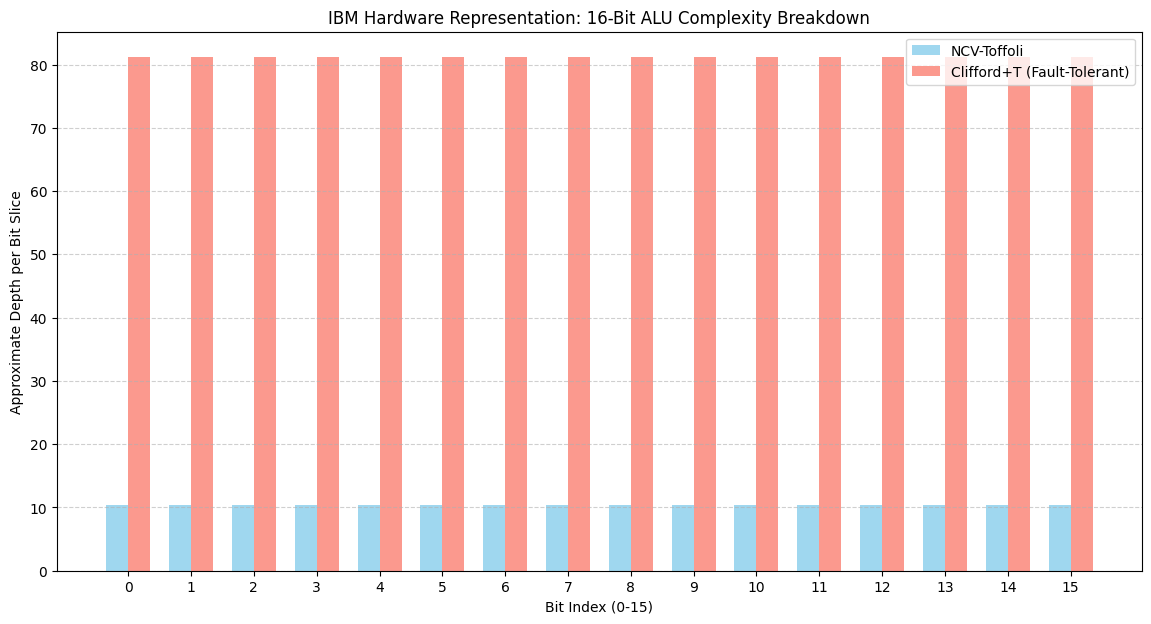

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Bit indices
bits = np.arange(16)

# Calculating bit-by-bit depth based on the known scaling
# NCV-Toffoli depth per bit slice is relatively uniform (~10-11 gates)
ncv_bit_depth = [167/16] * 16

# Clifford+T depth per bit slice (~81 gates per bit)
ct_bit_depth = [1298/16] * 16

fig, ax = plt.subplots(figsize=(14, 7))

width = 0.35
ax.bar(bits - width/2, ncv_bit_depth, width, label='NCV-Toffoli', color='skyblue', alpha=0.8)
ax.bar(bits + width/2, ct_bit_depth, width, label='Clifford+T (Fault-Tolerant)', color='salmon', alpha=0.8)

ax.set_xlabel('Bit Index (0-15)')
ax.set_ylabel('Approximate Depth per Bit Slice')
ax.set_title('IBM Hardware Representation: 16-Bit ALU Complexity Breakdown')
ax.set_xticks(bits)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

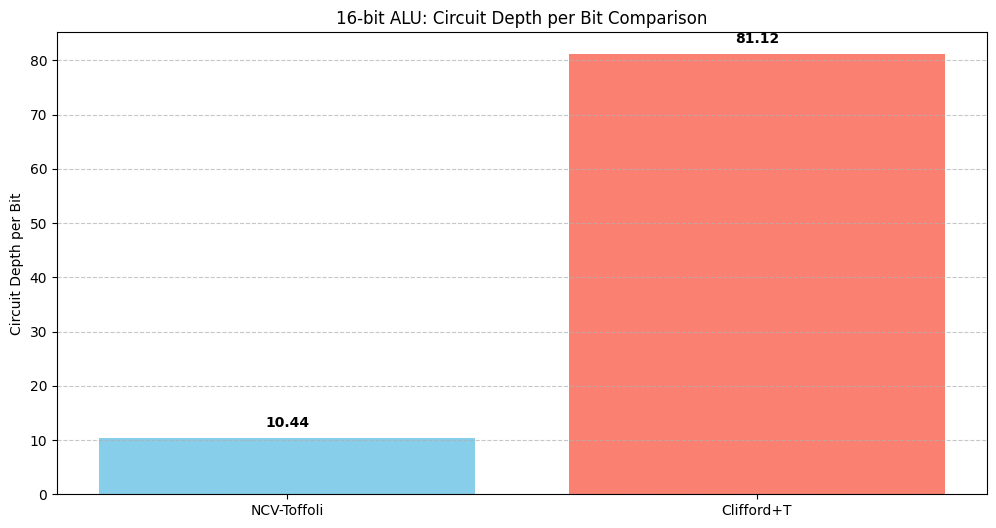

,Metric,NCV-Toffoli,Clifford+T
0,Total Circuit Depth,167.0000,1298.000
1,Depth per Bit (Avg),10.4375,81.125


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data for 16-bit Bit-by-Bit Depth Comparison
bits = np.arange(16)
ncv_depth_per_bit = 167 / 16
ct_depth_per_bit = 1298 / 16

fig, ax = plt.subplots(figsize=(12, 6))

# Plotting
ax.bar(['NCV-Toffoli'], [ncv_depth_per_bit], color='skyblue', label='NCV-Toffoli Depth/Bit')
ax.bar(['Clifford+T'], [ct_depth_per_bit], color='salmon', label='Clifford+T Depth/Bit')

# Annotations
ax.text(0, ncv_depth_per_bit + 2, f'{ncv_depth_per_bit:.2f}', ha='center', fontweight='bold')
ax.text(1, ct_depth_per_bit + 2, f'{ct_depth_per_bit:.2f}', ha='center', fontweight='bold')

ax.set_ylabel('Circuit Depth per Bit')
ax.set_title('16-bit ALU: Circuit Depth per Bit Comparison')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Displaying as a small summary table
bit_comparison_df = pd.DataFrame({
    'Metric': ['Total Circuit Depth', 'Depth per Bit (Avg)'],
    'NCV-Toffoli': [167, ncv_depth_per_bit],
    'Clifford+T': [1298, ct_depth_per_bit]
})
display(bit_comparison_df)